In [61]:
#om
import rasterio as rs 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

In [48]:
B02=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B02_20m.jp2").read(1)

In [49]:
B03=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B03_20m.jp2").read(1)

In [50]:
B04=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B04_20m.jp2").read(1)

In [51]:
B05=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B05_20m.jp2").read(1)

In [52]:
B06=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B06_20m.jp2").read(1)

In [53]:
B07=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B07_20m.jp2").read(1)

In [54]:
B8A=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B8A_20m.jp2").read(1)

In [55]:
B11=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B11_20m.jp2").read(1)

In [56]:
B12=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_B12_20m.jp2").read(1)

In [57]:
image_stack = np.dstack((B02, B03, B04, B05, B06, B07, B8A, B11, B12))
image_stack=image_stack/65535.0

In [58]:
scl=rs.open(r"C:\Users\vigne\Downloads\ISRO dataset\S2B_MSIL2A_20260313T050649_N0512_R019_T43PGQ_20260313T091002.SAFE\GRANULE\L2A_T43PGQ_A047092_20260313T052208\IMG_DATA\R20m\T43PGQ_20260313T050649_SCL_20m.jp2").read(1)

In [59]:
patches = []
label_patches = [] # Need a new list for labels

for i in range(0, 5426, 64):
    for j in range(0, 5426, 64):
        
        #  to slice the image:
        img_patch = image_stack[i:i+64, j:j+64]
        patches.append(img_patch)
        #to slice the scl
        sclp = scl[i:i+64, j:j+64]
        label_patches.append(sclp)

In [64]:
model = models.Sequential()

#Input and Encoder (shrinking the 9 bands)
model.add(layers.Input(shape=(64,64,9)))
model.add(layers.Conv2D(32,(3,3),activation='relu', padding='same'))
model.add(layers.MaxPool2D((2,2)))

# Decoder (expanding back to 64x64)
model.add(layers.UpSampling2D((2,2)))
model.add(layers.Conv2D(32,(3,3),activation='relu',padding='same'))

#Final Output (12 probabilities per pixel)
model.add(layers.Conv2D(12, (1, 1), activation='softmax'))

#compilation
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 32)     │         2,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 12)     │           396 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,268 (47.92 KB)

 Trainable params: 12,268 (47.92 KB)

 Non-trainable params: 0 (0.00 B)

In [65]:
import numpy as np
from sklearn.model_selection import train_test_split

In [66]:
X = np.array(patches)
Y = np.array(label_patches)

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=0.2)

model.fit(X_train,Y_train, epochs=10)

Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 34s 138ms/step - accuracy: 0.7942 - loss: 0.7755
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 24s 131ms/step - accuracy: 0.8968 - loss: 0.2876
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 21s 117ms/step - accuracy: 0.9163 - loss: 0.2381
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.9248 - loss: 0.2105
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 21s 116ms/step - accuracy: 0.9271 - loss: 0.1979
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 21s 114ms/step - accuracy: 0.9281 - loss: 0.1922
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.9288 - loss: 0.1894
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 20s 110ms/step - accuracy: 0.9303 - loss: 0.1849
Epoch 9/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 20s 111ms/step - accuracy: 0.9324 - loss: 0.1791
Epoch 10/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 22s 119ms/step - accuracy: 0.9353 - loss: 0.1716


In [67]:
model.evaluate(X_test,Y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 3s 53ms/step - accuracy: 0.9374 - loss: 0.1634


[0.16338619589805603, 0.9374072551727295]

1/1 ━━━━━━━━━━━━━━━━━━━━ 125s 125s/step


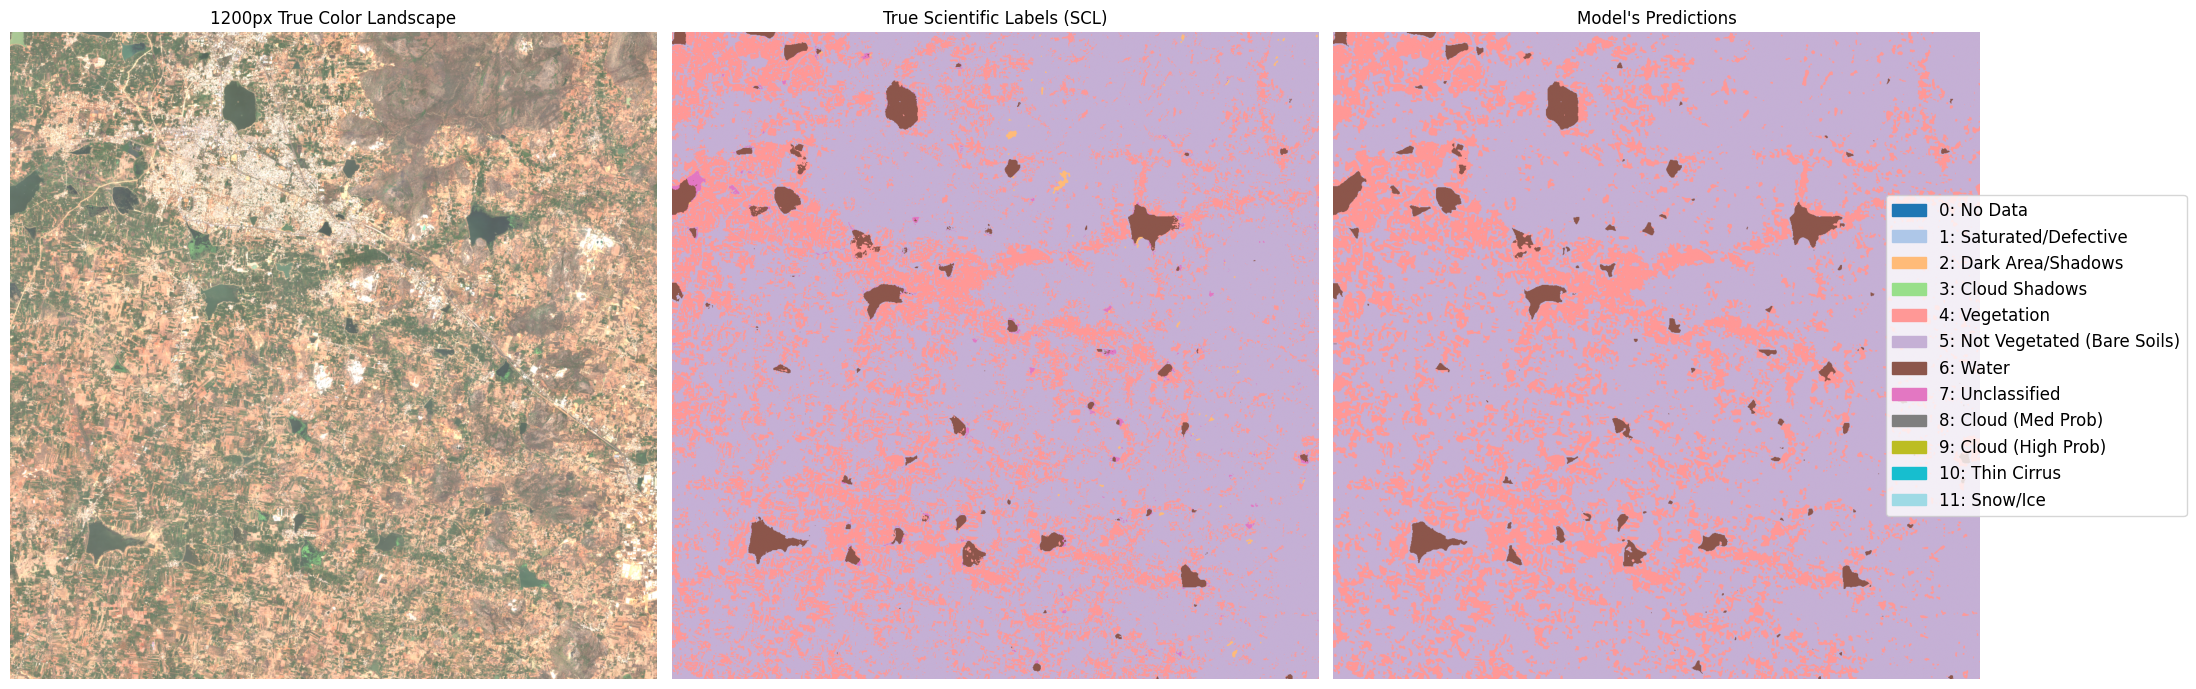

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- CHANGE THESE NUMBERS TO EXPLORE DIFFERENT AREAS ---
big_img = image_stack[1000:2200, 1000:2200]
big_scl = scl[1000:2200, 1000:2200]



big_img_batch = np.expand_dims(big_img, axis=0)

# 1. Create the True-Color RGB Image
rgb_img = big_img[:, :, [2, 1, 0]]
rgb_img = np.clip(rgb_img / (3000.0/65535.0), 0, 1)

# 2. Get the AI Predictions
big_pred = model.predict(big_img_batch)
big_labels = np.argmax(big_pred, axis=-1)[0]

# 3 Plots
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(20, 8))

# Plot 1: True Color Image
axes[0].imshow(rgb_img)
axes[0].set_title("1200px True Color Landscape")
axes[0].axis('off')

# Plot 2: True SCL Labels
im_scl = axes[1].imshow(big_scl, cmap='tab20', vmin=0, vmax=11)
axes[1].set_title("True Scientific Labels (SCL)")
axes[1].axis('off')

# Plot 3: AI Output
im_ai = axes[2].imshow(big_labels, cmap='tab20', vmin=0, vmax=11)
axes[2].set_title("Model's Predictions")
axes[2].axis('off')


scl_names = {
    0: "No Data", 1: "Saturated/Defective", 2: "Dark Area/Shadows", 
    3: "Cloud Shadows", 4: "Vegetation", 5: "Not Vegetated (Bare Soils)", 
    6: "Water", 7: "Unclassified", 8: "Cloud (Med Prob)", 
    9: "Cloud (High Prob)", 10: "Thin Cirrus", 11: "Snow/Ice"
}

cmap = plt.get_cmap('tab20')
legend_patches = [mpatches.Patch(color=cmap(i/11.0), label=f"{i}: {scl_names[i]}") for i in range(12)]
fig.legend(handles=legend_patches, loc='center right', bbox_to_anchor=(1.10, 0.5), fontsize=12)

plt.tight_layout()
plt.show()


Saving the Model

In [76]:
model.save("model.h5")

Exporting visualization of a 3x3 slidind window of the CNN

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.animation import FuncAnimation

#15x15 slice of raw satellite image
grid = X_test[0, 15:30, 15:30, 2] 


fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(grid, cmap='gray', vmax=(3000.0/65535.0))
ax.axis('off')
ax.set_title("3x3 Conv2D Kernel Sliding Over Sentinel-2 Data", fontsize=14, pad=20)

kernel_box = patches.Rectangle((-0.5, -0.5), 3, 3, linewidth=3, edgecolor='red', facecolor='none')
ax.add_patch(kernel_box)

def update(frame):
    
    row_idx = frame // 13
    col_idx = frame % 13
    
    # Move the red box to the new coordinates
    kernel_box.set_xy((col_idx - 0.5, row_idx - 0.5))
    return kernel_box,

# animation
anim = FuncAnimation(fig, update, frames=169, interval=100, blit=True)

#Save it 
anim.save('my_custom_convolution.gif', writer='pillow')
print("Successfully saved 'my_custom_convolution.gif' to your folder!")


plt.close()


Successfully saved 'my_custom_convolution.gif' to your folder!
